# Aplicación Astronómica: Distancia vs. Redshift (SN Simuladas)

En este notebook trabajaremos con un conjunto simulado de datos de supernovas tipo Ia, relacionando el redshift (z) con el módulo de distancia. Incluiremos outliers artificiales y aplicaremos modelos de regresión robusta.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, HuberRegressor, RANSACRegressor, TheilSenRegressor

np.random.seed(0)


## Generación de datos simulados de supernovas

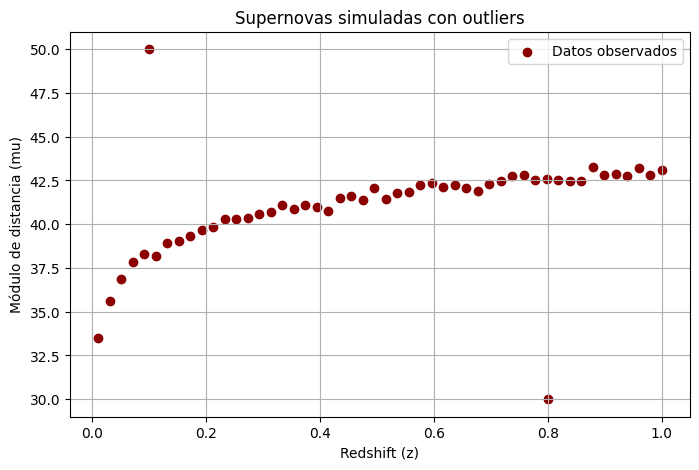

In [6]:
# Simulamos redshifts en el rango 0 < z < 1
z = np.linspace(0.01, 1.0, 50)
# Modelo teórico: distancia (simplificado como 5 * log10(D) + 25)
# Asumimos D = z * c / H0, con H0=70, c=300000 km/s (simplificación cosmológica)
mu = 5 * np.log10((3e5 / 70) * z) + 25  # módulo de distancia
mu_noise = mu + np.random.normal(0, 0.2, z.shape)

# Insertamos outliers
z_out = np.append(z, [0.1, 0.8])
mu_out = np.append(mu_noise, [50, 30])

plt.figure(figsize=(8, 5))
plt.scatter(z_out, mu_out, color='darkred', label='Datos observados')
plt.xlabel("Redshift (z)")
plt.ylabel("Módulo de distancia (mu)")
plt.title("Supernovas simuladas con outliers")
plt.grid(True)
plt.legend()
plt.show()


## Aplicación de modelos de regresión robusta

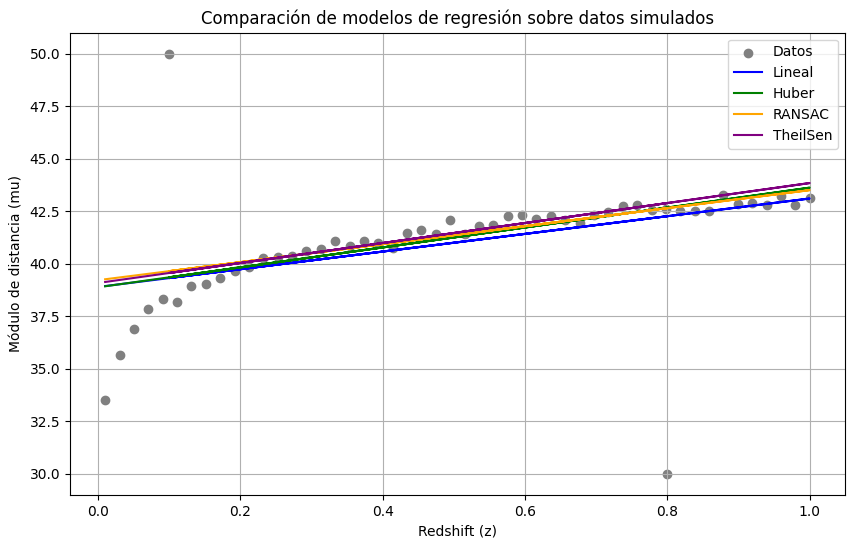

In [3]:
z_out_reshape = z_out.reshape(-1, 1)

models = {
    "Lineal": LinearRegression(),
    "Huber": HuberRegressor(),
    "RANSAC": RANSACRegressor(),
    "TheilSen": TheilSenRegressor()
}

plt.figure(figsize=(10, 6))
plt.scatter(z_out, mu_out, color='gray', label='Datos')

colors = ['blue', 'green', 'orange', 'purple']

for (name, model), color in zip(models.items(), colors):
    model.fit(z_out_reshape, mu_out)
    pred = model.predict(z_out_reshape)
    plt.plot(z_out, pred, label=name, color=color)

plt.xlabel("Redshift (z)")
plt.ylabel("Módulo de distancia (mu)")
plt.title("Comparación de modelos de regresión sobre datos simulados")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
from sklearn.metrics import mean_squared_error

sigma = 0.2  # error estimado por observación
n = len(mu_out)
nu = n - 2  # número de grados de libertad (2 parámetros)

print("Chi-cuadrado reducido por modelo:")
for name, model in models.items():
    y_pred = model.predict(z_out.reshape(-1, 1))
    chi2 = np.sum(((mu_out - y_pred) / sigma) ** 2)
    chi2_red = chi2 / nu
    print(f"{name:10}: χ²_reducido = {chi2_red:.2f}")

Chi-cuadrado reducido por modelo:
Lineal    : χ²_reducido = 163.18
Huber     : χ²_reducido = 165.47
RANSAC    : χ²_reducido = 166.57
TheilSen  : χ²_reducido = 169.45
